In [1]:
import pandas as pd
import numpy as np


# DATA CLEANING

### 1.LOAD DATA

In [2]:
df=pd.read_csv('sentimentdataset.csv')

In [3]:
df.shape
print(df)

     Unnamed: 0.1  Unnamed: 0  \
0               0           0   
1               1           1   
2               2           2   
3               3           3   
4               4           4   
..            ...         ...   
727           728         732   
728           729         733   
729           730         734   
730           731         735   
731           732         736   

                                                  Text    Sentiment  \
0     Enjoying a beautiful day at the park!        ...   Positive     
1     Traffic was terrible this morning.           ...   Negative     
2     Just finished an amazing workout! 💪          ...   Positive     
3     Excited about the upcoming weekend getaway!  ...   Positive     
4     Trying out a new recipe for dinner tonight.  ...   Neutral      
..                                                 ...          ...   
727  Collaborating on a science project that receiv...       Happy    
728  Attending a surprise birthday 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [5]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')

#### 2. DROP THE DUPLICATE COLUMN

In [6]:
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'],inplace=True)
print("Columns after drop:",df.columns.tolist())

Columns after drop: ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [7]:
df.head(10)

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9
6,Rainy days call for cozy blankets and hot coc...,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14
7,The new movie release is a must-watch! ...,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19
8,Political discussions heating up on the timel...,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8
9,Missing summer vibes and beach days. ...,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12


### 3. STRIP COULMNS

In [8]:
str_cols=['Text','Sentiment','User','Platform','Hashtags','Country']
for col in str_cols:
    df[col]=df[col].str.strip()

print(df.head())    

                                          Text Sentiment            Timestamp  \
0        Enjoying a beautiful day at the park!  Positive  2023-01-15 12:30:00   
1           Traffic was terrible this morning.  Negative  2023-01-15 08:45:00   
2          Just finished an amazing workout! 💪  Positive  2023-01-15 15:45:00   
3  Excited about the upcoming weekend getaway!  Positive  2023-01-15 18:20:00   
4  Trying out a new recipe for dinner tonight.   Neutral  2023-01-15 19:55:00   

         User   Platform            Hashtags  Retweets  Likes    Country  \
0     User123    Twitter       #Nature #Park      15.0   30.0        USA   
1   CommuterX    Twitter   #Traffic #Morning       5.0   10.0     Canada   
2  FitnessFan  Instagram   #Fitness #Workout      20.0   40.0        USA   
3  AdventureX   Facebook  #Travel #Adventure       8.0   15.0         UK   
4    ChefCook  Instagram      #Cooking #Food      12.0   25.0  Australia   

   Year  Month  Day  Hour  
0  2023      1   15    12  


In [9]:
df.head(3)

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


### 4. MISSING VALUE

In [10]:
df.isnull().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

### 5. FIX DATA TYPES

In [11]:
# df.columns
df[['Timestamp','Retweets','Likes']]

,Timestamp,Retweets,Likes
0,2023-01-15 12:30:00,15.0,30.0
1,2023-01-15 08:45:00,5.0,10.0
2,2023-01-15 15:45:00,20.0,40.0
3,2023-01-15 18:20:00,8.0,15.0
4,2023-01-15 19:55:00,12.0,25.0
...,...,...,...
727,2017-08-18 18:20:00,20.0,39.0
728,2018-06-22 14:15:00,25.0,48.0
729,2019-04-05 17:30:00,22.0,42.0
730,2020-02-29 20:45:00,21.0,43.0


In [12]:
df['Timestamp']=pd.to_datetime(df['Timestamp'], errors='coerce')

In [13]:
df['Retweets']=df['Retweets'].astype(int)
df['Retweets']

0      15
1       5
2      20
3       8
4      12
       ..
727    20
728    25
729    22
730    21
731    24
Name: Retweets, Length: 732, dtype: int64

In [14]:
df['Likes']=df['Likes'].astype(int)
df['Likes']

0      30
1      10
2      40
3      15
4      25
       ..
727    39
728    48
729    42
730    43
731    47
Name: Likes, Length: 732, dtype: int64

In [15]:
df

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20,39,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25,48,USA,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22,42,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21,43,UK,2020,2,29,20


### 6. REMOVE DUPLICATED

In [16]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().any()

np.False_

In [18]:
df.duplicated().sum()

np.int64(0)

### 7. RESET INDEX

In [19]:
df.reset_index(drop=True,inplace=True)
df.shape
df.columns
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


# DATA TRANSFORMATION

### 1. RENAME THE COLUMNS

In [20]:
df.columns
print()
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [21]:
df.rename(columns={'Text': 'Post','User':'Username'},inplace=True)
print()
df.columns

Index(['Post', 'Sentiment', 'Timestamp', 'Username', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='str')

### 2. TEXT-NUMBER

In [22]:
df

,Post,Sentiment,Timestamp,Username,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
705,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20,39,UK,2017,8,18,18
706,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25,48,USA,2018,6,22,14
707,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22,42,Canada,2019,4,5,17
708,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21,43,UK,2020,2,29,20


In [23]:
df['Sentiment'].unique()
print()
df['Sentiment'].value_counts()

Sentiment
Positive                45
Joy                     44
Excitement              37
Neutral                 18
Contentment             18
                        ..
Creative Inspiration     1
Runway Creativity        1
Ocean's Freedom          1
Whispers of the Past     1
Relief                   1
Name: count, Length: 191, dtype: int64

In [24]:
sentiment_map={
    'Positive': 1,'Negative':-1,'Neutral': 0,'Happy':3,'Sad':-2,'Hate':-3,'Bad':-2
}
df['Sentiment_map']=df['Sentiment'].map(sentiment_map)
print()
df.head (3)

,Post,Sentiment,Timestamp,Username,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_map
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,1.0
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,-1.0
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15,1.0


In [25]:
df[['Sentiment','Sentiment_map']].value_counts()

Sentiment  Sentiment_map
Positive    1.0             45
Neutral     0.0             18
Happy       3.0             14
Sad        -2.0              9
Hate       -3.0              6
Bad        -2.0              6
Negative   -1.0              4
Name: count, dtype: int64

###  3.DATA TYPES CHANGES FOR TIMESTAMP

In [26]:
df['Year']=df['Timestamp'].dt.year
df['Month']=df['Timestamp'].dt.month
df['Day']=df['Timestamp'].dt.day
df['Hour']=df['Timestamp'].dt.hour
print()
df.head(3)

,Post,Sentiment,Timestamp,Username,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_map
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,1.0
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,-1.0
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15,1.0


### 4. FINAL

In [27]:
df.head()
# # print()
# df.columns
# # print()
# # df.shape
# # print()
# # df.info()

,Post,Sentiment,Timestamp,Username,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_map
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,1.0
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,-1.0
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15,1.0
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18,1.0
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19,0.0


# DATA ANALYSIS

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

### 1. BAR CHART FOR SENTIMENT

C:\Users\DELL LATITUDE I7\AppData\Local\Temp\ipykernel_11676\1627425035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Sentiment',palette='pastel')


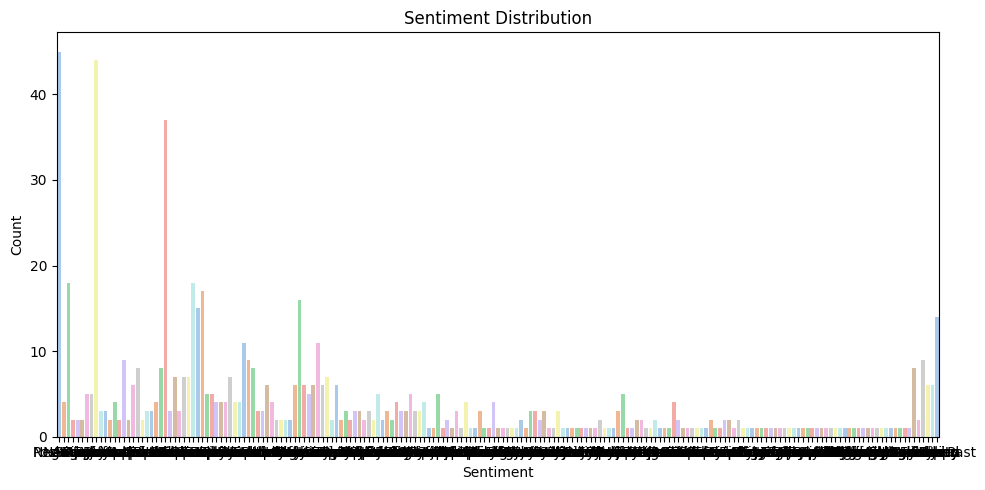

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Sentiment',palette='pastel')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


OBSERVATION:The bar chart compares the number of Positive, Neutral, and Negative sentiments.
It clearly shows which sentiment category has the highest frequency.
This helps understand the overall public opinion from the dataset.

### PIE CHART FOR PLATFORM USAGE

In [30]:
df.head(2)

,Post,Sentiment,Timestamp,Username,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_map
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,1.0
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,-1.0


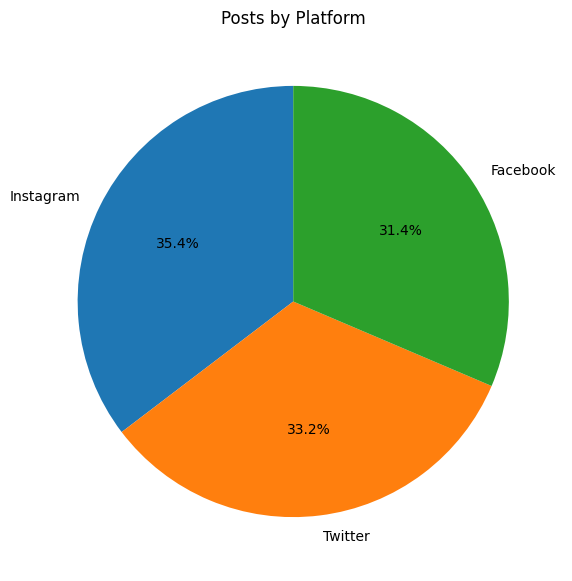

In [31]:
plt.figure(figsize=(7,7))
df['Platform'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Posts by Platform')
plt.ylabel('')
plt.show()

OBSERVATION:
The pie chart shows the percentage of usage for each platform. It helps compare the most and least used platforms in the dataset.

### 3. RETWEETS VS LIKES(SCATTER PLOT)

C:\Users\DELL LATITUDE I7\AppData\Local\Temp\ipykernel_11676\2270291316.py:4: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


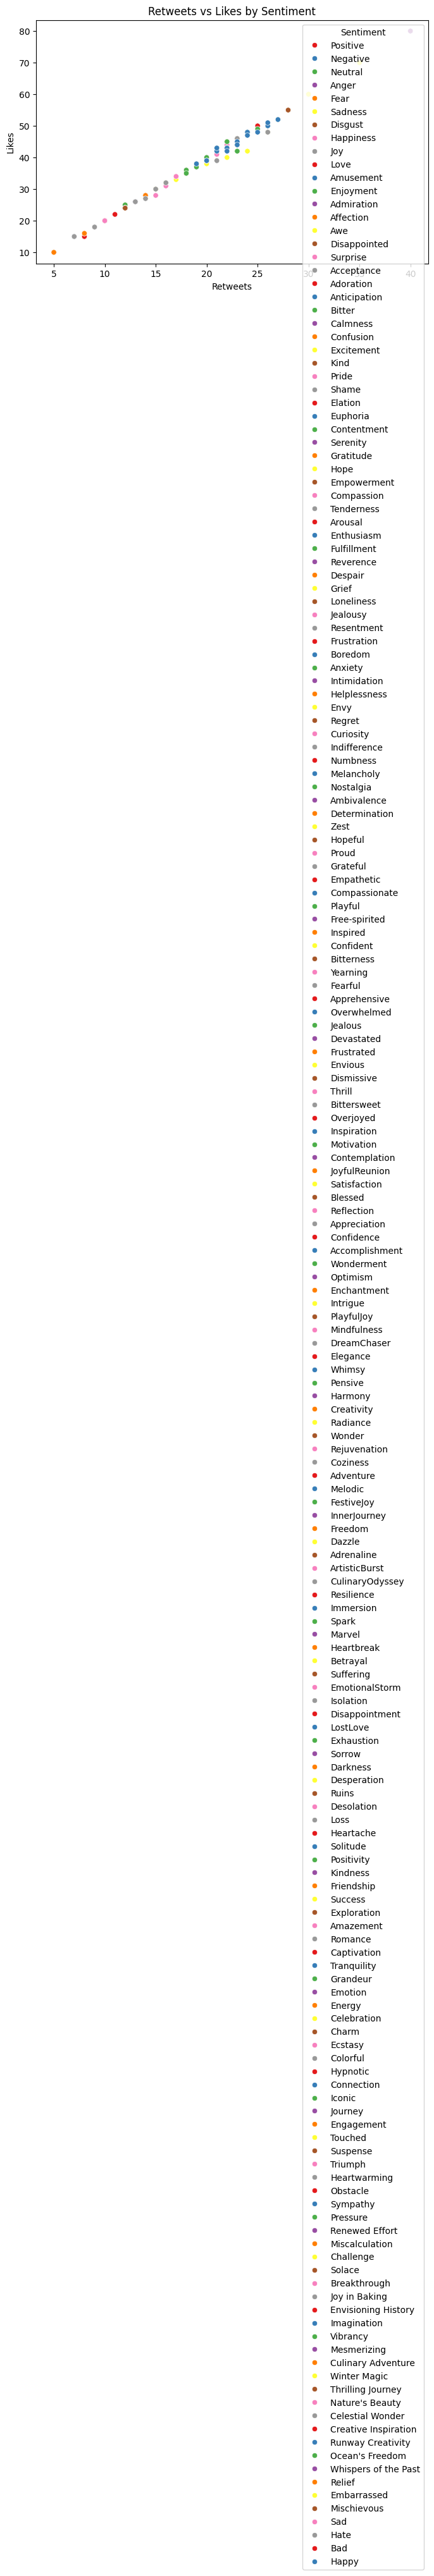

In [32]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Retweets', y='Likes', hue='Sentiment', palette='Set1')
plt.title('Retweets vs Likes by Sentiment')
plt.tight_layout()
plt.show()

OBSERVATION:
The scatter plot shows the relationship between retweets and likes.
Posts with more likes generally receive more retweets.
It helps identify highly engaging posts.

### 4.TOP 5 COUNTRIES (Bar Chart)

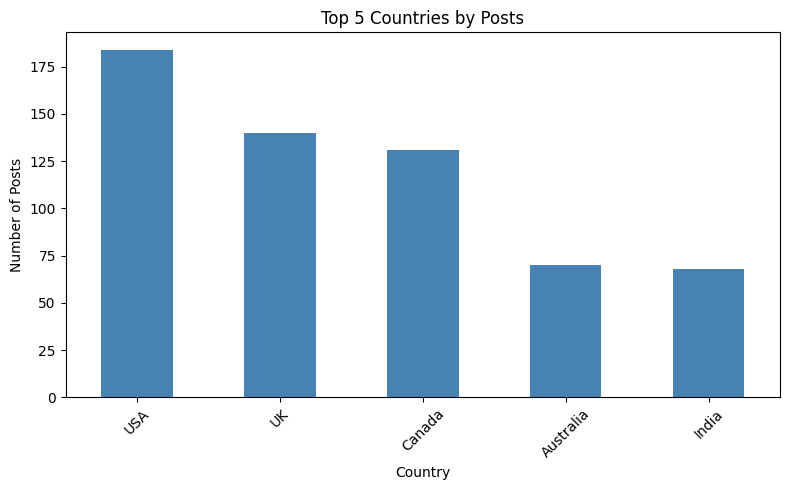

In [33]:

plt.figure(figsize=(8, 5))
df['Country'].value_counts().head(5).plot(kind='bar', color='steelblue')
plt.title('Top 5 Countries by Posts')
plt.xlabel('Country')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

OBSERVATION:
The bar chart shows the top 5 countries with the highest number of posts.
It helps compare the activity of different countries.
The country with the tallest bar has the highest number of posts.

### 5. POSTS BY MONTH (Line Chart)

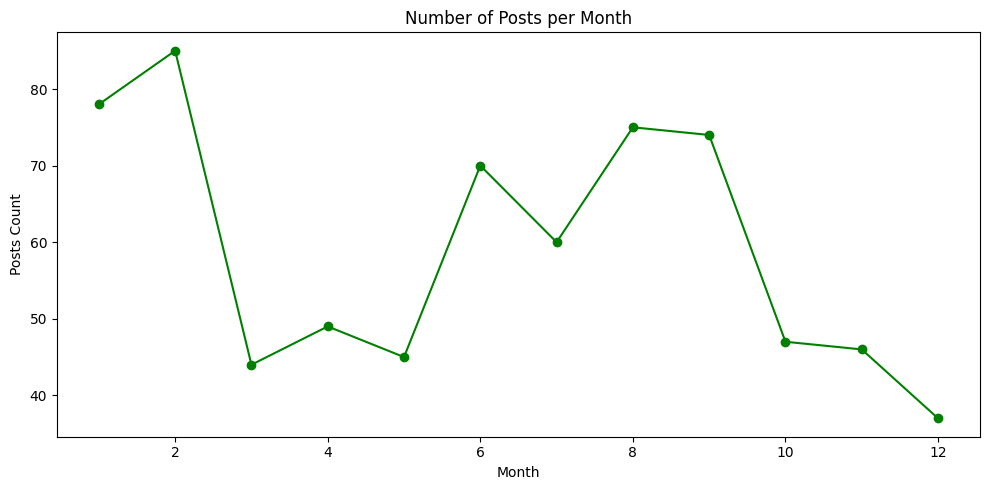

In [34]:

plt.figure(figsize=(10, 5))
df.groupby('Month')['Post'].count().plot(kind='line', marker='o', color='green')
plt.title('Number of Posts per Month')
plt.xlabel('Month')
plt.ylabel('Posts Count')
plt.tight_layout()
plt.show()

OBSERVATION:
The line chart shows the number of posts published each month.
It helps identify the trend in posting activity over time.
Peaks indicate months with higher activity, while dips indicate lower activity.

### 6. LIKES DISTRIBUTION (Histogram)

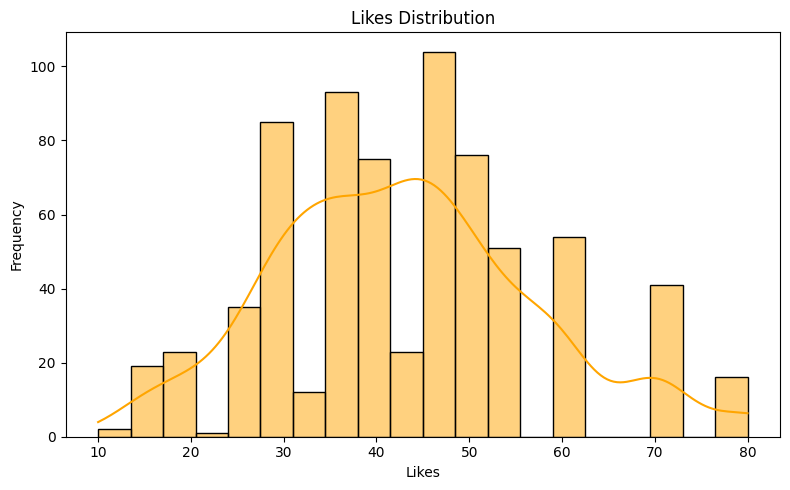

In [35]:

plt.figure(figsize=(8, 5))
sns.histplot(df['Likes'], bins=20, kde=True, color='orange')
plt.title('Likes Distribution')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

OBSERVATION:
The histogram shows the distribution of likes.
It helps understand how likes are spread across posts.
Most posts receive a similar number of likes.

### 7. CORRELATION HEATMAP

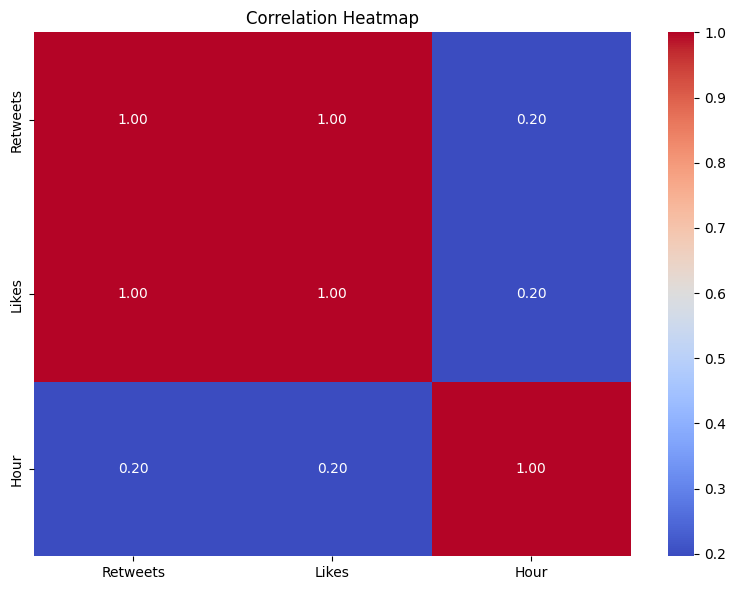

In [36]:

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Retweets', 'Likes', 'Hour']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

OBSERVATION:
The heatmap shows the relationship between different variables.
It helps identify strong and weak correlations.
Darker colors indicate stronger correlations.

In [37]:
df.head

<bound method NDFrame.head of                                                   Post Sentiment  \
0                Enjoying a beautiful day at the park!  Positive   
1                   Traffic was terrible this morning.  Negative   
2                  Just finished an amazing workout! 💪  Positive   
3          Excited about the upcoming weekend getaway!  Positive   
4          Trying out a new recipe for dinner tonight.   Neutral   
..                                                 ...       ...   
705  Collaborating on a science project that receiv...     Happy   
706  Attending a surprise birthday party organized ...     Happy   
707  Successfully fundraising for a school charity ...     Happy   
708  Participating in a multicultural festival, cel...     Happy   
709  Organizing a virtual talent show during challe...     Happy   

              Timestamp                             Username   Platform  \
0   2023-01-15 12:30:00                              User123    Twitter   
1  

In [38]:
df.columns

print()

df.head(3)

,Post,Sentiment,Timestamp,Username,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_map
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,1.0
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,-1.0
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15,1.0


### CONCLUSION: 
####          This project cleaned social media and analysed sentiment, engagement, and posting patterns. It showed that positive posts are most common and that likes and retweets tend to go up together.
      